# Subsystem Phase 2: Hierarchical Concept Modeling

This notebook implements Phase 2 of the high-level component discovery plan, focused on:
1. Subsystem Identification
2. Subsystem Refinement
   - 2.1.1 Embedding-Based Refinement
   - 2.1.2 LLM-Based Refinement
3. Hierarchical Organization
4. Subsystem Documentation

It generates the data that can be visualized in the `subsystem_visualization.ipynb` notebook.

## Setup and Imports

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import os
import sys
import json
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path
from loguru import logger as log
from collections import defaultdict, Counter
from typing import Dict, List, Tuple, Set, Any

os.environ.pop("http_proxy", None)
os.environ.pop("https_proxy", None)
os.environ.pop("HTTP_PROXY", None)
os.environ.pop("HTTPS_PROXY", None)

PROJECT_ROOT = Path('../..').resolve()  # Adjust as needed to find the project root

# Add the modules directory to the Python path if needed
modules_dir = PROJECT_ROOT / 'modules'
if str(modules_dir) not in sys.path:
    sys.path.append(str(modules_dir))

import subsystem_utils as su
from doc_db import DocumentDB, docs_db
import subsystem_identifier as si
import hierarchy_builder as hb
import subsystem_documenter as sd
import embedding_refiner as er
import llm_refiner as lr
import doxygen_graph as dg
import doxygen_parse as dp

## Load Resources from Phase 1

In [7]:
# Define paths
GRAPH_PATH = su.DEFAULT_GRAPH_PATH
DB_PATH = su.DEFAULT_DB_PATH
CLUSTERS_PATH = su.INTERNAL_DIR / "structural_clusters.json"

# Create directories if they don't exist
os.makedirs(su.VISUALIZATIONS_DIR, exist_ok=True)
os.makedirs(su.SUBSYSTEMS_DIR, exist_ok=True)

# Load graph
log.info(f"Loading graph from {GRAPH_PATH}...")
graph = su.load_graph(GRAPH_PATH)
log.info(f"Loaded graph with {len(graph.nodes())} nodes and {len(graph.edges())} edges.")

# Load entity database
log.info(f"Loading entity database from {DB_PATH}...")
entity_db = su.load_entity_db(DB_PATH)
log.info(f"Loaded entity database with {len(entity_db.entities)} entries.")

# Load document database
log.info("Loading document database...")
log.info(f"Loaded document database with {len(docs_db)} entries.")

# Load clusters
print(f"Loading clusters from {CLUSTERS_PATH}...")
clusters = su.load_clusters(CLUSTERS_PATH)
print(f"Loaded {len(clusters)} clusters.")

2025-06-26 16:14:27.695 | INFO     | __main__:<module>:11 - Loading graph from /Users/qte2333/repos/legacy/context/internal/code_graph.gml...
2025-06-26 16:14:29.362 | INFO     | doxygen_graph:load_graph:608 - Graph loaded from /Users/qte2333/repos/legacy/context/internal/code_graph.gml, nodes: 14507, edges: 44544
2025-06-26 16:14:29.504 | INFO     | __main__:<module>:13 - Loaded graph with 4549 nodes and 29174 edges.
2025-06-26 16:14:29.504 | INFO     | __main__:<module>:16 - Loading entity database from /Users/qte2333/repos/legacy/context/internal/code_graph.json...
2025-06-26 16:14:29.883 | INFO     | __main__:<module>:18 - Loaded entity database with 5305 entries.
2025-06-26 16:14:29.883 | INFO     | __main__:<module>:21 - Loading document database...
2025-06-26 16:14:29.884 | INFO     | __main__:<module>:22 - Loaded document database with 475 entries.


Loading clusters from /Users/qte2333/repos/legacy/context/internal/structural_clusters.json...
Loaded 26 clusters.


## Phase 2.1: Subsystem Identification

In [ ]:
# Generate subsystems from clusters
print("Analyzing clusters and generating subsystems...")
subsystems: Dict[su.SubsystemID, su.Subsystem] = si.process_clusters(clusters, entity_db, docs_db, graph)
print(f"Generated {len(subsystems)} subsystem definitions.")

# Save subsystems
SUBSYSTEMS_PATH = su.INTERNAL_DIR / "subsystems.json"
su.save_subsystems(subsystems, SUBSYSTEMS_PATH)
print(f"Saved subsystem definitions to {SUBSYSTEMS_PATH}")

# Generate and save subsystems catalog
catalog_content = si.generate_subsystems_catalog(subsystems)
CATALOG_PATH = su.DOCS_DIR / "subsystems_catalog.md"

with open(CATALOG_PATH, 'w') as f:
    f.write(catalog_content)
    
print(f"Generated subsystems catalog at {CATALOG_PATH}")

print(catalog_content)

Analyzing clusters and generating subsystems...
Generated 26 subsystem definitions.
Saved subsystem definitions to /Users/qte2333/repos/legacy/context/internal/subsystems.json
Generated subsystems catalog at /Users/qte2333/repos/legacy/docs/subsystems_catalog.md
# Subsystems Catalog

This document catalogs the high-level subsystems identified in the Legacy MUD codebase.
Each subsystem has been named and classified according to its function in the overall system.

## Overview

Total subsystems identified: 26

## Subsystem Classification

Subsystems are classified into the following categories:

- **Core**: Essential game mechanics and systems
- **Interface**: User interaction and I/O
- **Support**: Supporting functionality and utilities
- **Data**: Data management and persistence
- **Extension**: Optional or add-on features

## Subsystems

### Core

#### Array String

**ID**: s9

**Entity Count**: 107

**Key Concepts**: array, string, print, parse, number



#### Battle Operator=

**ID*

## Phase 2.1.1: Embedding-Based Refinement

This phase uses CodeBERT embeddings to detect entities that might be better placed in different subsystems.

In [9]:
# Convert subsystems dict from the format {name: SubsystemDefinition} to {name: set(entity_ids)}
refiner = er.EmbeddingRefiner(entity_db, graph)

In [ ]:
embeddings_path = os.path.join(su.INTERNAL_DIR, "node_embeddings.npy")

if False:
    # Generate embeddings as a flat Dict[NodeID, Embedding]
    embeddings = refiner.generate_embeddings_for_subsystems(subsystems)
    node_embeddings = {node_id: embedding for subsystem in embeddings.values() for node_id, embedding in subsystem.items()}

    # Save flat embeddings to disk
    np.save(embeddings_path, node_embeddings)
    print(f"Saved subsystem embeddings to {embeddings_path}")
else:
    # Load flat embeddings from disk
    node_embeddings: Dict[su.NodeID, np.ndarray] = np.load(embeddings_path, allow_pickle=True).item()
    print(f"Loaded subsystem embeddings from {embeddings_path}")

    # Reconstruct the embeddings mapping of SubsystemID to NodeID/Embedding pairs
    embeddings = {
        subsystem_id: {node_id: node_embeddings[node_id] for node_id in subsystem.nodes if node_id in node_embeddings}
        for subsystem_id, subsystem in subsystems.items()
    }

Loaded subsystem embeddings from /Users/qte2333/repos/legacy/context/internal/node_embeddings.npy


In [18]:
from structural_clustering import identify_utility_nodes


def calc_utility_score(score: Dict[str, float]) -> bool:
    etypes = ('calls', 'uses')
    return (
        ((
            sum(score[f'fan_in_{etype}'] for etype in etypes) +
            sum(score[f'fan_in_clusters_{etype}'] for etype in etypes) +
            0
        )/2) 
        * 
        (1-(
            sum(score[f'fan_out_{etype}'] for etype in etypes) + # calls, uses, inherits
            sum(score[f'fan_out_clusters_{etype}'] for etype in etypes) +
            sum(score[f'overlap_{etype}'] for etype in etypes) + # overlap - higher value means more used outside its cluster
            0
        )/2)
    )

node_to_subsystem_dict = {node_id: subsystem_id for subsystem_id, subsystem in subsystems.items() for node_id in subsystem.nodes}
utility_nodes = identify_utility_nodes(
    graph,
    lambda score: calc_utility_score(score) > 0.226,
    {node_id: s_id for s_id, s in subsystems.items() for node_id in s.nodes}
)
print(len(utility_nodes))

2025-06-26 20:33:02.658 | INFO     | structural_clustering:identify_utility_nodes:35 - Identifying utility nodes
2025-06-26 20:33:02.659 | INFO     | structural_clustering:identify_utility_nodes:39 - Calculating in/out degree for 4549 nodes
2025-06-26 20:33:02.669 | INFO     | structural_clustering:identify_utility_nodes:43 - Computing betweenness centrality (this may take a while for large graphs)
2025-06-26 20:33:17.326 | INFO     | structural_clustering:identify_utility_nodes:103 - Utility scores saved to utility_scores.json
2025-06-26 20:33:17.331 | INFO     | structural_clustering:identify_utility_nodes:119 - Identified 52 utility nodes in 14.67s


52


Loading CodeBERT model and tokenizer...
Model loaded successfully.
/**
 * @fn Area & Room::area() const
 *
 * @brief Returns a reference to the Area object associated with this Room instance.
 *
 * @details This function accesses the static Area context linked to the Room by returning the 'area' member from the Room's prototype object. Since the 'area' is stored within the RoomPrototype, this method provides a read-only way to retrieve the containing Area for the Room, facilitating queries about the room's regional properties or for comparison purposes. As a const member function, it guarantees not to modify the Room's state, making it suitable for use in various read-only game logic operations such as area-based filtering, quest placement, or environment checks across different parts of the codebase.
 *
 * @note This method relies on the Room's prototype to determine its Area, emphasizing the design where static properties are separated from dynamic state. It enables efficient access 

Token indices sequence length is longer than the specified maximum sequence length for this model (611 > 512). Running this sequence through the model will result in indexing errors


/**
 * @fn int atoi(const String &astr)
 *
 * @brief Converts a custom String object to an integer value.
 *
 * @details This function extracts the underlying C-style null-terminated string from the provided String object using the c_str() method, then converts this string to an integer using the standard atoi function. It acts as a simple wrapper to enable direct conversion from the custom String class to an integer, which is useful in various parsing and numeric processing scenarios within the codebase. The implementation depends on the underlying atoi function for the actual conversion, ensuring compatibility with standard C++ string handling. This design allows seamless integration of the custom String class with existing numeric conversion routines.
 *
 * @note The function assumes that the String contains a valid numeric representation; behavior is undefined if the string does not represent a valid integer.
 *
 * @rationale This function is used whenever a String object needs to 

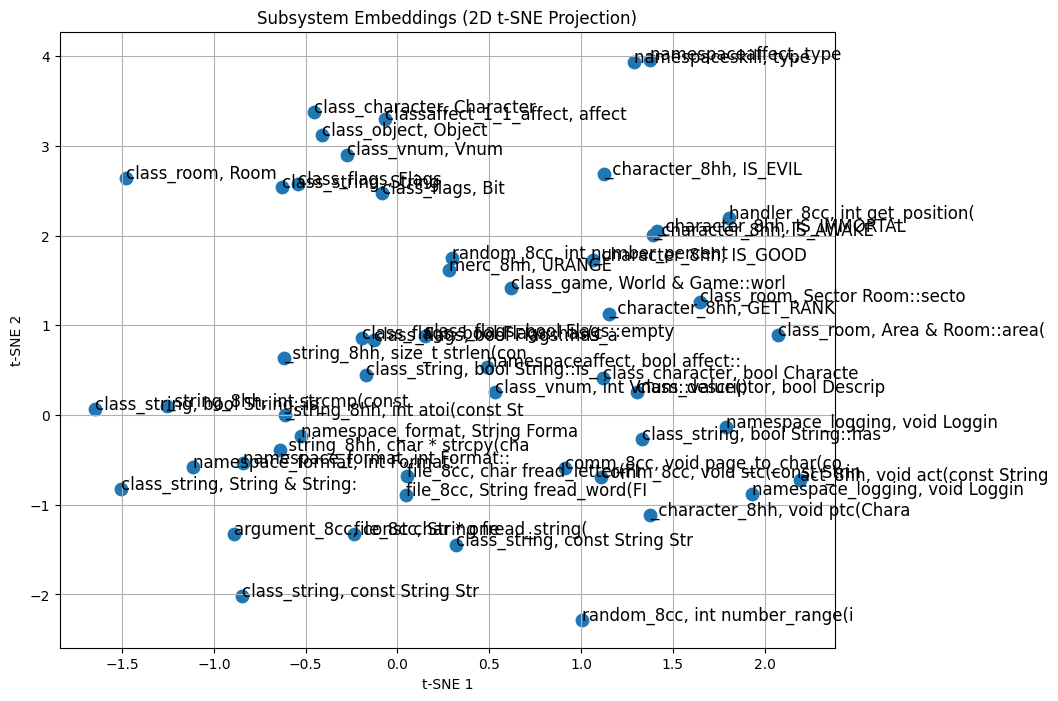

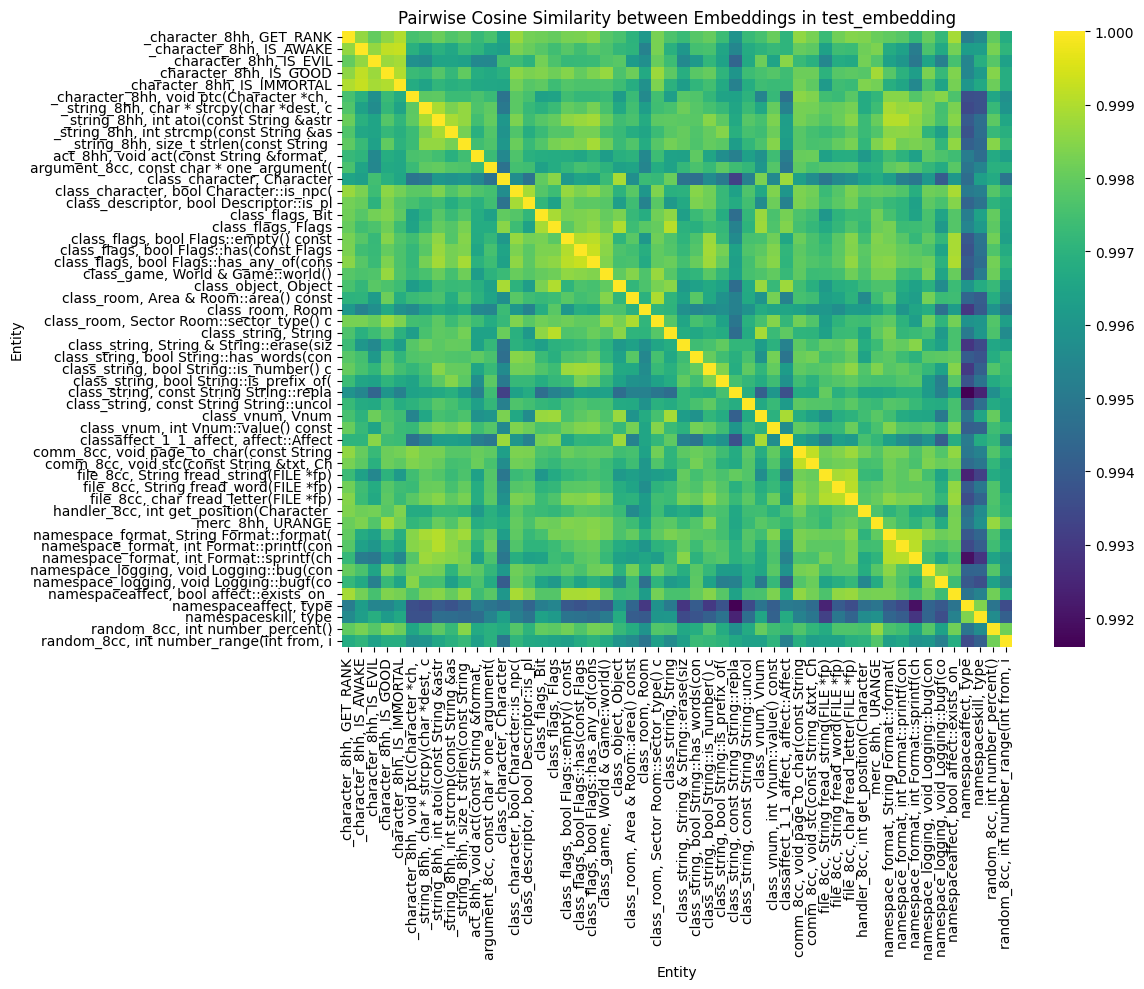

In [21]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import doxygen_graph as dg

name_embedding_map = {}
for node_id in utility_nodes:
    eid = dg.get_body_eid(entity_db, node_id)
    entity = entity_db.get(eid)
    embedding = refiner.generate_node_embedding(node_id)
    name_embedding_map[f"{entity.id.compound}, {entity.signature}"] = embedding

labels = list(name_embedding_map.keys())
X = np.stack([name_embedding_map[label] for label in labels])
labels = [k[:30] for k in labels]  # Truncate labels for better visibility

# Reduce to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=80)

for i, label in enumerate(labels):
    plt.text(X_2d[i, 0], X_2d[i, 1], label, fontsize=12)

plt.title("Subsystem Embeddings (2D t-SNE Projection)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.show()

# Compute pairwise cosine similarity
labels = sorted(name_embedding_map.keys())
emb_matrix = np.stack([name_embedding_map[label] for label in labels])
labels = [k[:40] for k in labels]  # Truncate labels for better visibility
cos_sim = cosine_similarity(emb_matrix)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cos_sim, xticklabels=labels, yticklabels=labels, cmap='viridis', annot=False)
plt.title("Pairwise Cosine Similarity between Embeddings in test_embedding")
plt.xlabel("Entity")
plt.ylabel("Entity")
plt.tight_layout()
plt.show()

In [7]:
import torch
from transformers import AutoTokenizer, AutoModel

CODEBERT_MODEL = "microsoft/codebert-base"
tokenizer = AutoTokenizer.from_pretrained(CODEBERT_MODEL)
model = AutoModel.from_pretrained(CODEBERT_MODEL)

def get_docstring(node_id):
    import doxygen_graph
    eid = doxygen_graph.get_body_eid(entity_db, node_id)
    entity = entity_db.get(eid)
    doc = docs_db.get_doc(entity.id.compound, entity.signature)
    return doc.to_doxygen()

def generate_embedding(tokenizer, model, text, MAX_TOKEN_LENGTH=512):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=MAX_TOKEN_LENGTH)

    with torch.no_grad():
        outputs = model(**inputs)
        # Use CLS token for sentence-level embedding
        embedding = outputs.last_hidden_state[:, 0, :].numpy()

    return embedding[0]

def generate_embedding_mean_pool(tokenizer, model, text, MAX_TOKEN_LENGTH=512):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=MAX_TOKEN_LENGTH)
    with torch.no_grad():
        outputs = model(**inputs)
        last_hidden = outputs.last_hidden_state
        attention_mask = inputs['attention_mask'].unsqueeze(-1)
        masked_hidden = last_hidden * attention_mask
        sum_hidden = masked_hidden.sum(dim=1)
        lengths = attention_mask.sum(dim=1)
        embedding = sum_hidden / lengths
    return embedding[0].numpy()

from sentence_transformers import SentenceTransformer
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")  # or all-mpnet-base-v2

def embed_sbert(docstring):
    return sbert_model.encode(docstring, convert_to_numpy=True, normalize_embeddings=True)

test_embedding = {}
for node_id in [
    'class_mob_prog',
    'group___gate_flags'
]:
    docstring = get_docstring(node_id)
    print(docstring)
#    test_embedding[node_id] = generate_embedding(tokenizer, model, docstring)
#    test_embedding[node_id] = generate_embedding_mean_pool(tokenizer, model, docstring)
    test_embedding[node_id] = embed_sbert(docstring)

from sklearn.metrics.pairwise import cosine_similarity
matrix = np.stack(list(test_embedding.values()))
cs = cosine_similarity(matrix)
print(cs)


/**
 * @class MobProg
 *
 * @brief A class representing a mobile program, including its type, arguments, and command list for behavior scripting.
 *
 * @details The MobProg class models mobile programs used within the system to define behaviors and actions for mobile entities. It stores the program's type as a set of bit flags, an argument list for parameterization, and a command list that specifies the behavior scripts. The class provides static methods to convert between human-readable type names and internal bit flag representations, facilitating script parsing and debugging. The constructor initializes a MobProg instance by reading data from a file stream, supporting flexible configuration through external files. Its design includes private copy constructor and assignment operator to prevent unintended copying, ensuring resource safety and object integrity. This class integrates into the larger system architecture by enabling dynamic behavior assignment and management of mobile ent

In [8]:
import doxygen_graph as dg

test_embedding = sorted([e for e in embeddings.values() if len(e) > 30], key=len)[1]

name_embedding_map = {}
for node_id, embedding in test_embedding.items():
    eid = dg.get_body_eid(entity_db, node_id)
    entity = entity_db.get(eid)
    name_embedding_map[f"{entity.id.compound}, {entity.signature}"] = embedding

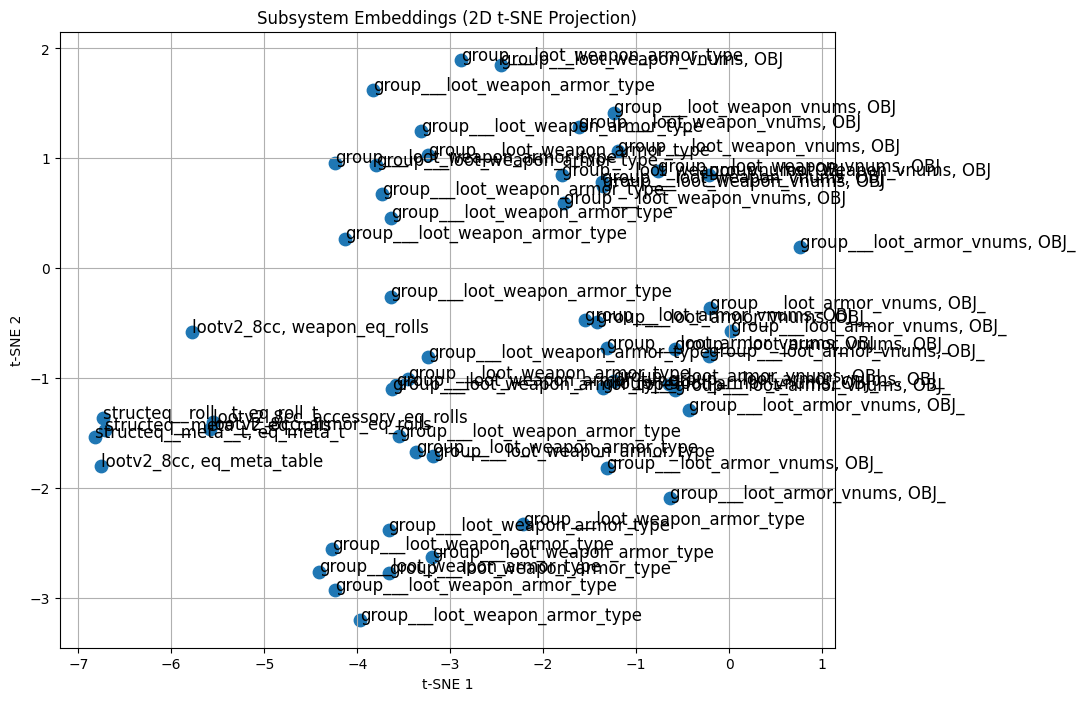

In [9]:
from math import trunc
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

# Prepare data for visualization

labels = list(name_embedding_map.keys())
X = np.stack([name_embedding_map[label] for label in labels])
labels = [k[:30] for k in labels]  # Truncate labels for better visibility

# Reduce to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=80)

for i, label in enumerate(labels):
    plt.text(X_2d[i, 0], X_2d[i, 1], label, fontsize=12)

plt.title("Subsystem Embeddings (2D t-SNE Projection)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.show()

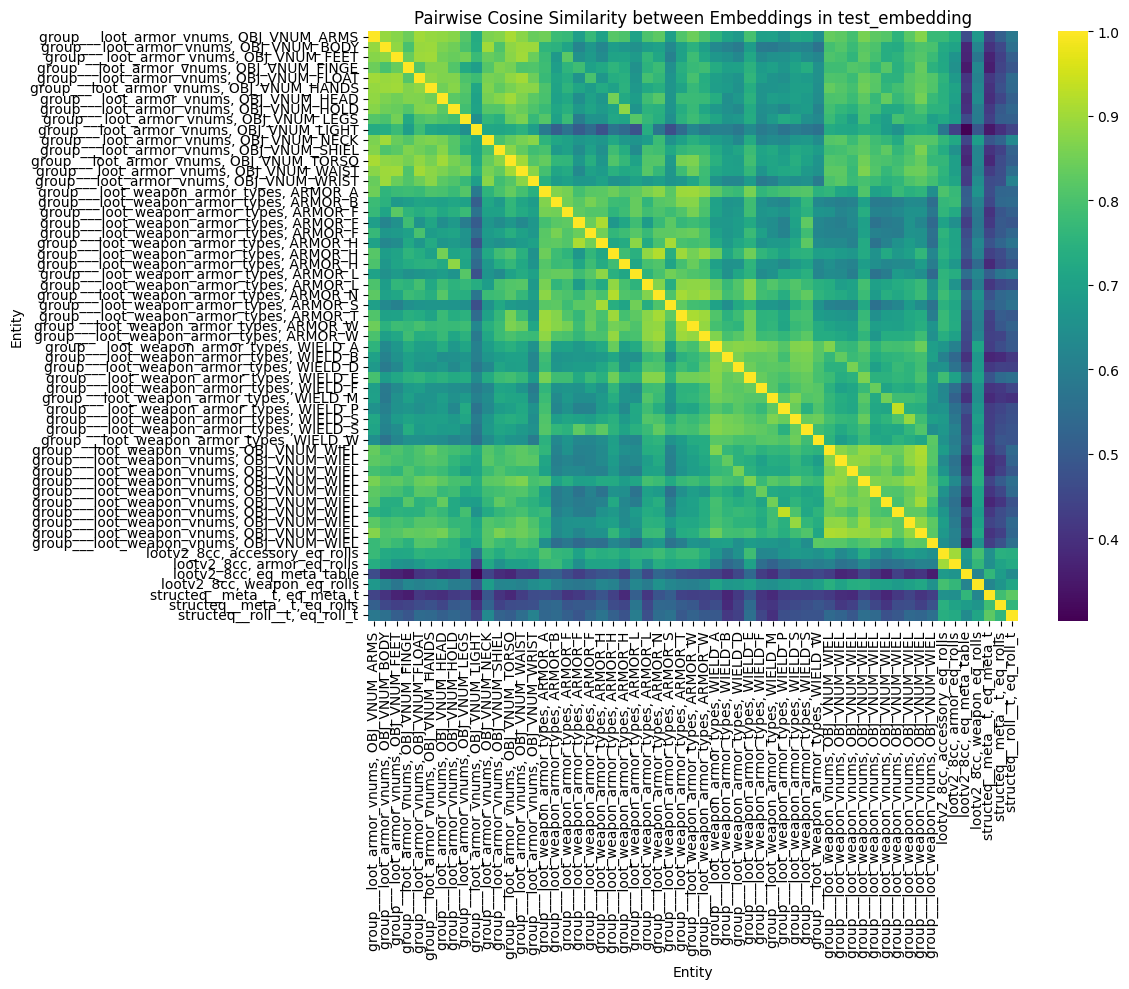

In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

# Compute pairwise cosine similarity
labels = sorted(name_embedding_map.keys())
emb_matrix = np.stack([name_embedding_map[label] for label in labels])
labels = [k[:40] for k in labels]  # Truncate labels for better visibility
cos_sim = cosine_similarity(emb_matrix)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cos_sim, xticklabels=labels, yticklabels=labels, cmap='viridis', annot=False)
plt.title("Pairwise Cosine Similarity between Embeddings in test_embedding")
plt.xlabel("Entity")
plt.ylabel("Entity")
plt.tight_layout()
plt.show()

In [15]:
def embedding_refine_subsystems(subsystems: Dict[su.SubsystemID, su.Subsystem], refiner: er.EmbeddingRefiner, entity_db: dp.EntityDatabase, CONFIDENCE_THRESHOLD=0.7):
    """
    Iteratively refine subsystems using embedding-based suggestions.
    Args:
        subsystems: dict of {name: Subsystem}
        refiner: EmbeddingRefiner instance
        entity_db: EntityDatabase
        CONFIDENCE_THRESHOLD: float
    Returns:
        new_subsystems: dict of {name: Subsystem}
        results: dict with refinement stats and suggestions
    """
    subsystem_embeddings: Dict[su.SubsystemID, Dict[su.NodeID, np.ndarray]] = {subsystem_id: {node_id: node_embeddings[node_id] for node_id in subsystem.nodes} for subsystem_id, subsystem in subsystems.items()}

    # Calculate similarity matrices within subsystems
    similarity_matrices = refiner.calculate_similarity_matrices(subsystem_embeddings)

    # Calculate similarities across subsystems
    cross_similarities = refiner.calculate_cross_subsystem_similarities(subsystem_embeddings)

    # Identify outliers within each subsystem
    outliers = refiner.identify_outliers(subsystems, similarity_matrices)

    # Suggest regroupings for outliers
    suggestions = refiner.suggest_regroupings(outliers, cross_similarities)

    # Create refined subsystems by applying high-confidence suggestions
    refined_subsystems = {name: su.Subsystem.from_dict(s.to_dict()) for name, s in subsystems.items()}
    applied_suggestions = []

    for suggestion in suggestions:
        eid = dg.get_body_eid(entity_db, suggestion['node_id'])
        entity = entity_db.get(eid)
        current = subsystems[suggestion['current_subsystem']]
        current_sim = suggestion['current_similarity']
        proposed = subsystems[suggestion['suggested_subsystem']]
        proposed_sim = suggestion['suggested_similarity']
        print(f"Suggestion: {f'{entity.id.compound}, {entity.name}'} from {current.name} ({current_sim}) -> {proposed.name} ({proposed_sim}) (Confidence: {suggestion['confidence']})")
        if suggestion['confidence'] > CONFIDENCE_THRESHOLD:
            node_id = suggestion['node_id']
            current = suggestion['current_subsystem']
            target = suggestion['suggested_subsystem']
            # Move node to suggested subsystem
            refined_subsystems[current].nodes.remove(node_id)
            refined_subsystems[target].nodes.add(node_id)
            applied_suggestions.append(suggestion)

    results = {
        'original_subsystems': {name: list(subsystem.nodes) for name, subsystem in subsystems.items()},
        'refined_subsystems': {name: list(subsystem.nodes) for name, subsystem in refined_subsystems.items()},
        'outliers': outliers,
        'suggestions': suggestions,
        'applied_suggestions': applied_suggestions,
        'stats': {
            'total_outliers': len(outliers),
            'total_suggestions': len(suggestions),
            'applied_suggestions': len(applied_suggestions)
        }
    }

    print(f"Refinement complete. Found {len(outliers)} outliers, made {len(suggestions)} suggestions, applied {len(applied_suggestions)}.")
    return refined_subsystems, results

# Example usage for one iteration:
refined_subsystems, results = embedding_refine_subsystems(subsystems, refiner, entity_db, CONFIDENCE_THRESHOLD=0.7)

Suggestion: declare_8hh, DECLARE_SPEC_FUN from Operator= Vnum (0.3880048394203186) -> Core typedef (0.8253614902496338) (Confidence: 1.0)
Suggestion: declare_8hh, SPEC_FUN from Operator= Vnum (0.43325677514076233) -> Core typedef (0.8184328079223633) (Confidence: 0.8806909236460234)
Suggestion: interp_8hh, DO_FUN from War Clan (0.4399179220199585) -> Core typedef (0.7942840456962585) (Confidence: 0.8102451923489706)
Suggestion: class_string, String from Name State (0.3469521999359131) -> Identifier Core (0.6974620223045349) (Confidence: 0.8014279003279943)
Suggestion: group___gem_value_fields, GEM_VALUE_QUALITY from Spec Act (0.3815780282020569) -> Quality Gem::quality (0.7289581298828125) (Confidence: 0.7942719083431197)
Suggestion: class_war, War from War Clan (0.3215620219707489) -> Battle Operator= (0.6646746397018433) (Confidence: 0.7845144622369058)
Suggestion: c_j_s_o_n_8h, cJSON_ArrayForEach from Edit Note (0.2171015739440918) -> Array String (0.5599178671836853) (Confidence: 0

In [16]:
refined_subsystems, results = embedding_refine_subsystems(refined_subsystems, refiner, entity_db, CONFIDENCE_THRESHOLD=0.7)

Suggestion: class_war, operator= from War Clan (0.3999222218990326) -> Battle Operator= (0.7609593868255615) (Confidence: 1.0)
Suggestion: class_auction, Auction from Operator= Weather (0.26102206110954285) -> Battle Operator= (0.6217321753501892) (Confidence: 0.9990941356800508)
Suggestion: group___gem_value_fields, GEM_VALUE_TYPE from Spec Act (0.37944841384887695) -> Quality Gem::quality (0.7400805354118347) (Confidence: 0.99887811172112)
Suggestion: class_duel, Duel from Duel Char (0.3301362097263336) -> Battle Operator= (0.684418797492981) (Confidence: 0.9812911860161095)
Suggestion: class_war_1_1_event, operator= from War Clan (0.35506725311279297) -> Dispatcher Operator= (0.7080441117286682) (Confidence: 0.9776745800884683)
Suggestion: class_auction, operator= from Operator= Weather (0.2715097665786743) -> Battle Operator= (0.6217545866966248) (Confidence: 0.970107385452202)
Suggestion: class_character, operator= from Spec Act (0.342894047498703) -> Identifier Core (0.6770118474

## Phase 2.1.2: LLM-Based Refinement

This phase uses LLM to evaluate entity groupings based on semantic coherence and identify entities that might be better placed in different subsystems.

In [12]:
# Convert subsystems dict from the format {name: SubsystemDefinition} to {name: set(entity_ids)}
entity_subsystems = {}
for name, definition in subsystems.items():
    entity_subsystems[name] = set(definition.nodes)

test_subsystems = sorted((k,v) for k,v in entity_subsystems.items() if len(v) > 30)
test_subsystems = {k:v for k,v in test_subsystems[:1]}

# Use the llm_refiner module for LLM-based refinement
# Note: This is an optional step. You may want to comment it out if you 
# don't have access to OpenAI API or don't want to run LLM-based analysis
print("Starting LLM-based refinement of subsystems...")

# Set use_ollama=True to use local Ollama model instead of OpenAI
use_ollama = False  # Change to True to use local Ollama models

llm_results = lr.refine_subsystems_with_llm(
    entity_db, graph, test_subsystems, su.INTERNAL_DIR, use_ollama=use_ollama
)

# Get the refined subsystems with applied suggestions
llm_refined_subsystems = {}
for name, entities in llm_results['refined_subsystems'].items():
    # Create new subsystem definition with updated entities
    new_def = subsystems[name].copy()
    new_def.nodes = entities
    llm_refined_subsystems[name] = new_def

print(f"LLM-based refinement complete. Applied {llm_results['stats']['applied_suggestions']} regrouping suggestions.")

# Update the subsystems variable to use refined subsystems
subsystems = llm_refined_subsystems

# Save updated subsystems
LLM_REFINED_SUBSYSTEMS_PATH = su.INTERNAL_DIR / "llm_refined_subsystems.json"
su.save_subsystems(subsystems, LLM_REFINED_SUBSYSTEMS_PATH)
print(f"Saved LLM-refined subsystem definitions to {LLM_REFINED_SUBSYSTEMS_PATH}")

Starting LLM-based refinement of subsystems...
Starting LLM-based subsystem refinement...
Analyzing subsystem: s0 (80 entities)
# s0 Subsystem

Contains 80 entities:

- [variable] VT_RESTORECURSOR | Brief: A constant representing the VT100 escape sequence to restore the cursor's position and attributes. | Details: The `VT_RESTORECURSOR` constant stores the ANSI escape sequence used to restore the cursor's position and attributes to a previously saved state in terminal applications. It is typically sent to the terminal after temporary cursor movements or screen updates to revert the cursor to its original location, ensuring a seamless user experience. This sequence is used alongside cursor save commands and is fundamental for maintaining consistent cursor positioning during complex terminal interactions. It is initialized with the standard VT100 escape code for restoring the cursor position.
- [variable] REVERSE | Brief: A constant that represents the reverse video display mode in the a

KeyError: 'node_id'

## Phase 2.2: Hierarchical Organization

In [5]:
# Create hierarchical model using the hierarchy_builder module
print("Creating hierarchical model of subsystems...")
hierarchy, subsystem_graph = hb.create_hierarchical_model(subsystems, entity_db, graph)

# Save hierarchical model
HIERARCHY_PATH = su.INTERNAL_DIR / "system_hierarchy.json"
with open(HIERARCHY_PATH, 'w') as f:
    json.dump(hierarchy, f, indent=2)
    
print(f"Saved hierarchical model to {HIERARCHY_PATH}")

# Generate hierarchical view document
hierarchical_view_content = hb.generate_hierarchical_view_document(
    hierarchy, subsystems, subsystem_graph, entity_db, graph
)

# Save hierarchical view document
HIERARCHY_DOC_PATH = su.DOCS_DIR / "hierarchical_view.md"
with open(HIERARCHY_DOC_PATH, 'w') as f:
    f.write(hierarchical_view_content)
    
print(f"Saved hierarchical view document to {HIERARCHY_DOC_PATH}")

Creating hierarchical model of subsystems...
Saved hierarchical model to /Users/qte2333/repos/legacy/context/internal/system_hierarchy.json
Saved hierarchical view document to /Users/qte2333/repos/legacy/docs/hierarchical_view.md


## Phase 2.3: Subsystem Documentation

In [6]:
# Generate individual subsystem documentation
print("Generating individual subsystem documentation...")

# Use the subsystem_documenter module to generate documentation
sd.generate_all_subsystem_documents(
    subsystems, entity_db, graph, docs_db, su.SUBSYSTEMS_DIR
)

print(f"Generated documentation for {len(subsystems)} subsystems in {su.SUBSYSTEMS_DIR}")

Generating individual subsystem documentation...
Generated documentation for 47 subsystems in /Users/qte2333/repos/legacy/docs/subsystems
Generated documentation for 47 subsystems in /Users/qte2333/repos/legacy/docs/subsystems


## Summary of Generated Data

This notebook has generated the following data files:

1. **Subsystems data**:
   - Initial subsystem definitions: `context/internal/subsystems.json`
   - Subsystem catalog: `docs/subsystems_catalog.md`

2. **Refinement data**:
   - Embedding-refined subsystems: `context/internal/embedding_refined_subsystems.json`
   - Embedding refinement report: `docs/embedding_refinement_report.md` 
   - LLM-refined subsystems: `context/internal/llm_refined_subsystems.json`
   - LLM refinement report: `docs/llm_refinement_report.md`

3. **Hierarchical model**:
   - System hierarchy: `context/internal/system_hierarchy.json`
   - Hierarchical view document: `docs/hierarchical_view.md`

4. **Subsystem documentation**:
   - Individual documentation files: `docs/subsystems/*.md`

All this data can now be visualized and explored in the `subsystem_visualization.ipynb` notebook.